# Language Classifier (Model 2) — Kinyarwanda vs English
**Project:** SRH AI Platform — ALU Capstone
**Input:** `data/Language_Classifier_data/lang_{train,val,test}.csv`
**Output:** `models/language_classifier.pkl` + comparison chart + confusion matrix

Train-from-scratch (no pretrained language-ID libraries). **Key difference from the topic
classifier:** features are **CHARACTER n-gram TF-IDF** (`analyzer='char_wb'`,
`ngram_range=(2,5)`) — language ID keys on spelling/morphology, not vocabulary. This
matters for Kinyarwanda's agglutinative morphology, where word-level features generalise
poorly to unseen word forms. Same model family as the safety and topic classifiers:
Logistic Regression / Linear SVM (calibrated) / XGBoost.

---
## STEP 0 — Install dependencies

In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib
print('Dependencies ready.')

Dependencies ready.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## STEP 1 — Imports and config

In [2]:
import os, json, time, warnings, joblib, random, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)

def find_repo_root(start='.'):
    p = os.path.abspath(start)
    while True:
        if (os.path.isdir(os.path.join(p, 'data', 'Topic_Classifier_data'))
                or os.path.isdir(os.path.join(p, '.git'))):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            return os.path.abspath(start)
        p = parent

REPO_ROOT = find_repo_root()
DATA_DIR  = os.path.join(REPO_ROOT, 'data', 'Language_Classifier_data')
MODEL_DIR = os.path.join(REPO_ROOT, 'models'); os.makedirs(MODEL_DIR, exist_ok=True)
assert os.path.exists(os.path.join(DATA_DIR, 'lang_train.csv')), \
    'Run language_classifier_data_pipeline.ipynb first.'
print(f'Repo root      : {REPO_ROOT}')
print(f'Data directory : {DATA_DIR}')
print(f'Model directory: {MODEL_DIR}')

Repo root      : C:\Users\USER\srh-ml-model
Data directory : C:\Users\USER\srh-ml-model\data\Language_Classifier_data
Model directory: C:\Users\USER\srh-ml-model\models


---
## STEP 2 — Load splits & confirm class distribution

Splits  train=8,400  val=1,800  test=1,800


Leakage  train&val=0  train&test=0  val&test=0

Class distribution per split:
             train  val  test
english       4200  900   900
kinyarwanda   4200  900   900


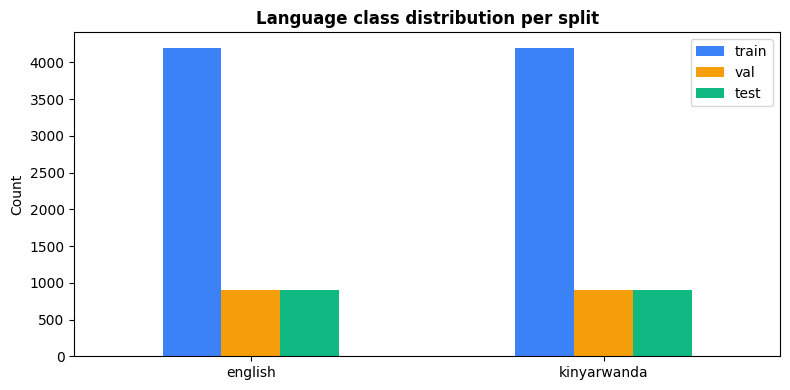

In [3]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'lang_train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'lang_val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'lang_test.csv'))
with open(os.path.join(DATA_DIR, 'lang_label_map.json')) as f:
    LMAP = json.load(f)
INT_TO_LANG = {int(k): v for k, v in LMAP['int_to_language'].items()}
CLASS_NAMES = [INT_TO_LANG[i] for i in range(len(INT_TO_LANG))]
POS_LABEL = 1  # kinyarwanda = positive class for binary F1 / ROC-AUC

for df in (train_df, val_df, test_df):
    df['text'] = df['text'].fillna('').astype(str)
    df['label'] = df['label'].astype(int)

print(f'Splits  train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')
def _keys(df): return set(df['text'].str.strip().str.lower())
print('Leakage  train&val={}  train&test={}  val&test={}'.format(
    len(_keys(train_df)&_keys(val_df)), len(_keys(train_df)&_keys(test_df)), len(_keys(val_df)&_keys(test_df))))

dist = pd.DataFrame({s: d['label'].value_counts().sort_index()
                     for s, d in [('train', train_df), ('val', val_df), ('test', test_df)]}).fillna(0).astype(int)
dist.index = [INT_TO_LANG[i] for i in dist.index]
print('\nClass distribution per split:'); print(dist.to_string())
ax = dist.plot(kind='bar', figsize=(8, 4), color=['#3B82F6', '#F59E0B', '#10B981'])
ax.set_title('Language class distribution per split', fontweight='bold'); ax.set_ylabel('Count')
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig_language_class_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

X_train, y_train = train_df['text'], train_df['label'].values
X_val,   y_val   = val_df['text'],   val_df['label'].values
X_test,  y_test  = test_df['text'],  test_df['label'].values

---
## STEP 3 — Feature extraction: CHARACTER n-gram TF-IDF
`char_wb` builds char n-grams within word boundaries (pads with spaces), so it captures
prefixes/suffixes/morphology. Fit on **train only**. Accents/apostrophes are kept (signal).

In [4]:
TFIDF_PARAMS = dict(
    analyzer      = 'char_wb',
    ngram_range   = (2, 5),
    max_features  = 50_000,
    sublinear_tf  = True,
    min_df        = 2,
    strip_accents = None,   # keep diacritics/apostrophes as language signal
    lowercase     = True,
)
def make_pipeline(clf):
    return Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', clf)])
print('Character n-gram TF-IDF configured (char_wb, 2-5, max 50k).')

Character n-gram TF-IDF configured (char_wb, 2-5, max 50k).


---
## STEP 4 — Define the three models

In [5]:
def _xgb_device():
    try:
        subprocess.run(['nvidia-smi'], capture_output=True, check=True); return 'cuda'
    except Exception:
        return 'cpu'
XGB_DEVICE = _xgb_device(); print(f'XGBoost device: {XGB_DEVICE}')

lr_pipeline  = make_pipeline(LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs',
                                                class_weight='balanced', random_state=RANDOM_SEED))
svm_pipeline = make_pipeline(CalibratedClassifierCV(
    LinearSVC(C=0.5, max_iter=5000, class_weight='balanced', random_state=RANDOM_SEED), cv=3))
xgb_pipeline = make_pipeline(XGBClassifier(objective='binary:logistic', n_estimators=300,
    max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', tree_method='hist', device=XGB_DEVICE,
    random_state=RANDOM_SEED, n_jobs=-1))
MODELS = {'Logistic Regression': lr_pipeline, 'Linear SVM': svm_pipeline, 'XGBoost': xgb_pipeline}
print('Models defined:'); [print(f'  - {n}') for n in MODELS]

XGBoost device: cpu
Models defined:
  - Logistic Regression
  - Linear SVM
  - XGBoost


[None, None, None]

---
## STEP 5 — Train & evaluate on the VALIDATION set
Test set untouched until Step 7.

In [6]:
results = {}
for name, pipeline in MODELS.items():
    print('\n' + '=' * 58); print(f'  Training: {name}'); print('=' * 58)
    fit_params = {}
    if name == 'XGBoost':
        fit_params['clf__sample_weight'] = compute_sample_weight('balanced', y_train)
    t0 = time.time(); pipeline.fit(X_train, y_train, **fit_params); train_time = time.time() - t0
    y_pred = pipeline.predict(X_val); y_prob = pipeline.predict_proba(X_val)[:, POS_LABEL]
    acc      = accuracy_score(y_val, y_pred)
    f1_bin   = f1_score(y_val, y_pred, pos_label=POS_LABEL, average='binary')
    f1_macro = f1_score(y_val, y_pred, average='macro')
    roc_auc  = roc_auc_score(y_val, y_prob)
    results[name] = {'accuracy': round(acc, 4), 'f1_binary': round(f1_bin, 4),
                     'f1_macro': round(f1_macro, 4), 'roc_auc': round(roc_auc, 4),
                     'train_sec': round(train_time, 1), 'pipeline': pipeline}
    print(f'  Train time : {train_time:.1f}s')
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  F1 (kinya) : {f1_bin:.4f}   <- selection metric (binary, pos=kinyarwanda)')
    print(f'  F1 Macro   : {f1_macro:.4f}')
    print(f'  ROC-AUC    : {roc_auc:.4f}')
    print('\n  Classification report (val):')
    print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, zero_division=0))
print('\nAll models trained.')


  Training: Logistic Regression


  Train time : 7.5s
  Accuracy   : 1.0000
  F1 (kinya) : 1.0000   <- selection metric (binary, pos=kinyarwanda)
  F1 Macro   : 1.0000
  ROC-AUC    : 1.0000

  Classification report (val):
              precision    recall  f1-score   support

     english       1.00      1.00      1.00       900
 kinyarwanda       1.00      1.00      1.00       900

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800


  Training: Linear SVM


  Train time : 7.5s
  Accuracy   : 0.9994
  F1 (kinya) : 0.9994   <- selection metric (binary, pos=kinyarwanda)
  F1 Macro   : 0.9994
  ROC-AUC    : 1.0000

  Classification report (val):
              precision    recall  f1-score   support

     english       1.00      1.00      1.00       900
 kinyarwanda       1.00      1.00      1.00       900

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800


  Training: XGBoost


  Train time : 204.8s
  Accuracy   : 0.9978
  F1 (kinya) : 0.9978   <- selection metric (binary, pos=kinyarwanda)
  F1 Macro   : 0.9978
  ROC-AUC    : 1.0000

  Classification report (val):
              precision    recall  f1-score   support

     english       1.00      1.00      1.00       900
 kinyarwanda       1.00      1.00      1.00       900

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800


All models trained.


---
## STEP 6 — Model comparison & selection (by binary F1)

Model comparison (sorted by binary F1):
              Model  Accuracy  F1 (kinya)  F1 Macro  ROC-AUC  Train (s)
Logistic Regression    1.0000      1.0000    1.0000      1.0        7.5
         Linear SVM    0.9994      0.9994    0.9994      1.0        7.5
            XGBoost    0.9978      0.9978    0.9978      1.0      204.8

Best model: Logistic Regression  (F1 = 1.0)


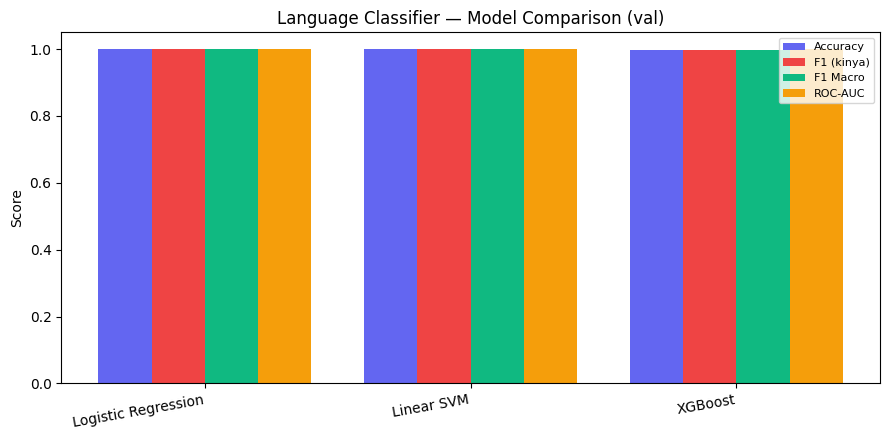

Saved: C:\Users\USER\srh-ml-model\models/fig_language_model_comparison.png


In [7]:
rows = [{'Model': n, 'Accuracy': r['accuracy'], 'F1 (kinya)': r['f1_binary'],
         'F1 Macro': r['f1_macro'], 'ROC-AUC': r['roc_auc'], 'Train (s)': r['train_sec']}
        for n, r in results.items()]
comparison = pd.DataFrame(rows).sort_values('F1 (kinya)', ascending=False).reset_index(drop=True)
print('Model comparison (sorted by binary F1):'); print(comparison.to_string(index=False))
best_name = comparison.iloc[0]['Model']; best_pipeline = results[best_name]['pipeline']
print(f'\nBest model: {best_name}  (F1 = {results[best_name]["f1_binary"]})')

fig, ax = plt.subplots(figsize=(9, 4.5))
models = comparison['Model'].tolist(); x = np.arange(len(models)); w = 0.2
ax.bar(x-1.5*w, comparison['Accuracy'],   width=w, label='Accuracy',   color='#6366F1')
ax.bar(x-0.5*w, comparison['F1 (kinya)'], width=w, label='F1 (kinya)', color='#EF4444')
ax.bar(x+0.5*w, comparison['F1 Macro'],   width=w, label='F1 Macro',   color='#10B981')
ax.bar(x+1.5*w, comparison['ROC-AUC'],    width=w, label='ROC-AUC',    color='#F59E0B')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=10, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.set_title('Language Classifier — Model Comparison (val)')
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig_language_model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {MODEL_DIR}/fig_language_model_comparison.png')

---
## STEP 7 — Evaluate the best model on the held-out TEST set
⚠️ **Run once.**

TEST SET RESULTS — Logistic Regression
  Accuracy   : 1.0000
  F1 (kinya) : 1.0000
  F1 Macro   : 1.0000
  ROC-AUC    : 1.0000

              precision    recall  f1-score   support

     english       1.00      1.00      1.00       900
 kinyarwanda       1.00      1.00      1.00       900

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



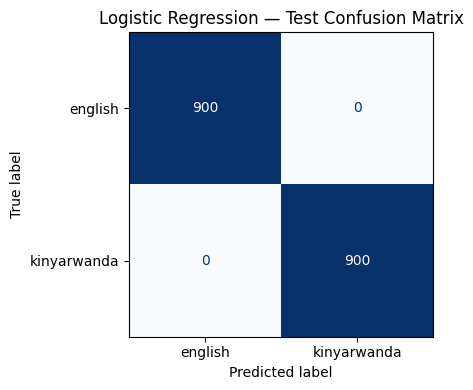

Saved: C:\Users\USER\srh-ml-model\models/fig_language_confusion_matrix.png


In [8]:
y_pred_test = best_pipeline.predict(X_test)
y_prob_test = best_pipeline.predict_proba(X_test)[:, POS_LABEL]
test_acc      = accuracy_score(y_test, y_pred_test)
test_f1_bin   = f1_score(y_test, y_pred_test, pos_label=POS_LABEL, average='binary')
test_f1_macro = f1_score(y_test, y_pred_test, average='macro')
test_auc      = roc_auc_score(y_test, y_prob_test)
print(f'TEST SET RESULTS — {best_name}')
print(f'  Accuracy   : {test_acc:.4f}')
print(f'  F1 (kinya) : {test_f1_bin:.4f}')
print(f'  F1 Macro   : {test_f1_macro:.4f}')
print(f'  ROC-AUC    : {test_auc:.4f}\n')
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES, zero_division=0))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, display_labels=CLASS_NAMES,
    colorbar=False, cmap='Blues', ax=ax)
ax.set_title(f'{best_name} — Test Confusion Matrix'); plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig_language_confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {MODEL_DIR}/fig_language_confusion_matrix.png')

---
## STEP 8 — Save the winning pipeline + metadata

In [9]:
joblib.dump(best_pipeline, f'{MODEL_DIR}/language_classifier.pkl')
meta = {'model': 'Model 2 — Language Classifier (Kinyarwanda vs English)',
        'best_model': best_name, 'classes': CLASS_NAMES,
        'features': 'Character n-gram TF-IDF (char_wb, 2-5, max 50k)',
        'val_metrics': {k: results[best_name][k] for k in ['accuracy','f1_binary','f1_macro','roc_auc']},
        'test_metrics': {'accuracy': round(test_acc,4), 'f1_binary': round(test_f1_bin,4),
                         'f1_macro': round(test_f1_macro,4), 'roc_auc': round(test_auc,4)},
        'rows': {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}}
with open(f'{MODEL_DIR}/language_classifier_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Saved: {MODEL_DIR}/language_classifier.pkl'); print(json.dumps(meta, indent=2))

Saved: C:\Users\USER\srh-ml-model\models/language_classifier.pkl
{
  "model": "Model 2 \u2014 Language Classifier (Kinyarwanda vs English)",
  "best_model": "Logistic Regression",
  "classes": [
    "english",
    "kinyarwanda"
  ],
  "features": "Character n-gram TF-IDF (char_wb, 2-5, max 50k)",
  "val_metrics": {
    "accuracy": 1.0,
    "f1_binary": 1.0,
    "f1_macro": 1.0,
    "roc_auc": 1.0
  },
  "test_metrics": {
    "accuracy": 1.0,
    "f1_binary": 1.0,
    "f1_macro": 1.0,
    "roc_auc": 1.0
  },
  "rows": {
    "train": 8400,
    "val": 1800,
    "test": 1800
  }
}


---
## STEP 9 — Quick inference + short-query stress test

In [10]:
loaded = joblib.load(f'{MODEL_DIR}/language_classifier.pkl')
samples = [
    'Where can I get free condoms in Kigali?',
    'Ni hehe nabona uburyo bwo kuboneza urubyaro?',
    'What are the symptoms of an STI?',
    'Indwara zandurira mu mibonano mpuzabitsina ni izihe?',
    'umubyibuho ukabije',          # very short Kinyarwanda
    'HIV test',                    # very short English
    'Murakoze cyane',              # short Kinyarwanda greeting
]
preds = loaded.predict(pd.Series(samples))
print(f'{"Predicted":<13} Query'); print('-' * 70)
for q, p in zip(samples, preds): print(f'{INT_TO_LANG[int(p)]:<13} {q}')

Predicted     Query
----------------------------------------------------------------------
english       Where can I get free condoms in Kigali?
kinyarwanda   Ni hehe nabona uburyo bwo kuboneza urubyaro?
english       What are the symptoms of an STI?
kinyarwanda   Indwara zandurira mu mibonano mpuzabitsina ni izihe?
kinyarwanda   umubyibuho ukabije
english       HIV test
kinyarwanda   Murakoze cyane


---
## STEP 10 — Summary & caveats

In [11]:
print('=' * 64)
print('LANGUAGE CLASSIFIER (Model 2) — COMPLETE')
print('=' * 64)
print(f'  Winning model : {best_name}  (selected by binary F1)')
print(f'  Rows          : train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')
print('\n  Validation comparison:'); print(comparison.to_string(index=False))
print('\n  Held-out TEST metrics:')
print(f'    Accuracy   : {test_acc:.4f}')
print(f'    F1 (kinya) : {test_f1_bin:.4f}')
print(f'    F1 Macro   : {test_f1_macro:.4f}')
print(f'    ROC-AUC    : {test_auc:.4f}')
print('\n  Caveats:')
print('   - BINARY EN/RW only: no open labeled code-switch corpus was found, so')
print('     mixed Kinyarwanda-English text is NOT handled (future work).')
print('   - Char n-grams are robust on short queries, but 1-2 word inputs are the')
print('     hardest case (see the short-query stress test in Step 9).')
print('   - Domain skew: English is SRH/medical+safety text, Kinyarwanda is news+')
print('     general sentences; char-level LID is largely domain-robust but worth noting.')
print('=' * 64)

LANGUAGE CLASSIFIER (Model 2) — COMPLETE
  Winning model : Logistic Regression  (selected by binary F1)
  Rows          : train=8,400  val=1,800  test=1,800

  Validation comparison:
              Model  Accuracy  F1 (kinya)  F1 Macro  ROC-AUC  Train (s)
Logistic Regression    1.0000      1.0000    1.0000      1.0        7.5
         Linear SVM    0.9994      0.9994    0.9994      1.0        7.5
            XGBoost    0.9978      0.9978    0.9978      1.0      204.8

  Held-out TEST metrics:
    Accuracy   : 1.0000
    F1 (kinya) : 1.0000
    F1 Macro   : 1.0000
    ROC-AUC    : 1.0000

  Caveats:
   - BINARY EN/RW only: no open labeled code-switch corpus was found, so
     mixed Kinyarwanda-English text is NOT handled (future work).
   - Char n-grams are robust on short queries, but 1-2 word inputs are the
     hardest case (see the short-query stress test in Step 9).
   - Domain skew: English is SRH/medical+safety text, Kinyarwanda is news+
     general sentences; char-level LID is l